In [1]:
import librosa
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, medfilt
from scipy.ndimage import uniform_filter1d
import soundfile as sf

# Segmentación

In [2]:
SAMPLING_RATE = 16_000
HIGHCUT = 4_000

In [3]:
folder = '../audios_propios'

paths = []

for file in os.listdir(folder):
    if 'respiracion' in file:
        paths.append(os.path.join(folder, file))

paths


['../audios_propios\\respiracion.ogg',
 '../audios_propios\\respiracion2.ogg',
 '../audios_propios\\respiracion3.ogg',
 '../audios_propios\\respiracion4.ogg',
 '../audios_propios\\respiracion5.ogg']

La respiración 4 contiene un wheeze

## Pasos obligatorios del pipeline:

In [4]:
def bandpass(y, sr, lowcut=0, highcut=HIGHCUT, order=4):
    nyq = 0.5 * sr
    low = lowcut / nyq
    high = highcut / nyq
    if low == 0:
        b, a = butter(order, high, btype='low')
    else:
        b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, y)


def filter_and_resample(path, sr_target=SAMPLING_RATE, lowcut=0, highcut=HIGHCUT):
    y, sr = librosa.load(path, sr=None)
    y = bandpass(y, sr, lowcut=lowcut, highcut=highcut)
    if sr != sr_target:
        y = librosa.resample(y, orig_sr=sr, target_sr=sr_target)
    return y, sr_target

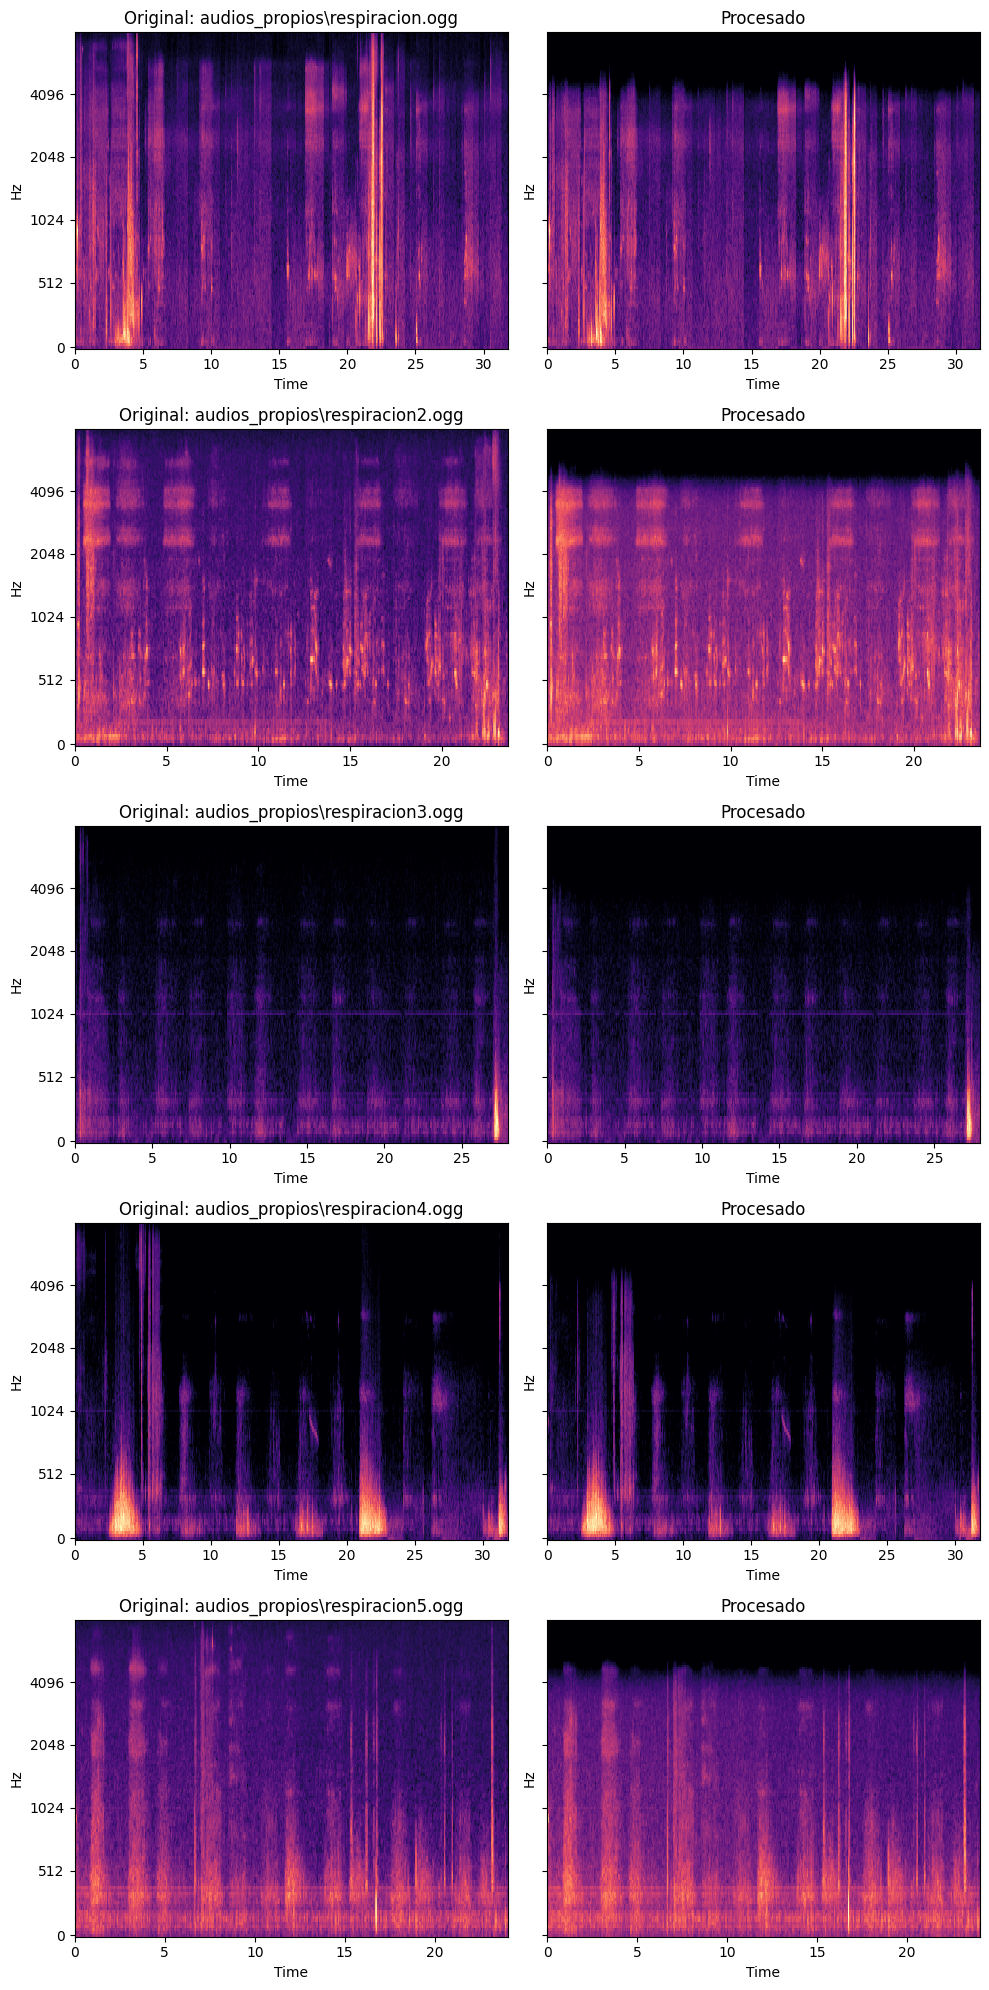

In [5]:
fig, axes = plt.subplots(len(paths), 2, figsize=(10, 4 * len(paths)), sharey=True)

for i, path in enumerate(paths):
    # Cargar original
    y, sr = librosa.load(path, sr=None)
    melspec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    melspec_db = librosa.power_to_db(melspec, ref=np.max)

    # Cargar procesado
    y_proc, sr_proc = filter_and_resample(path)
    melspec_proc = librosa.feature.melspectrogram(y=y_proc, sr=sr_proc, n_mels=128)
    melspec_proc_db = librosa.power_to_db(melspec_proc, ref=np.max)

    # Plot original
    ax_orig = axes[i, 0] if len(paths) > 1 else axes[0]
    img1 = librosa.display.specshow(
        melspec_db, sr=sr, x_axis='time', y_axis='mel', ax=ax_orig
    )
    ax_orig.set_title(f"Original: {path.split('/')[-1]}")
    # fig.colorbar(img1, ax=ax_orig, format="%+2.0f dB")

    # Plot procesado
    ax_proc = axes[i, 1] if len(paths) > 1 else axes[1]
    img2 = librosa.display.specshow(
        melspec_proc_db, sr=sr_proc, x_axis='time', y_axis='mel', ax=ax_proc
    )
    ax_proc.set_title("Procesado")
    # fig.colorbar(img2, ax=ax_proc, format="%+2.0f dB")

plt.tight_layout()
plt.show()


Esa "S" en el audio 4 segundo 17 es un wheeze, vi algo parecido en ICBHI

## Segmentación
Ahora vamos a lo más importante, somos capaces de dividir los audios en ciclos?

### Energy Based

Quizás conviene hacer sustraccion espectral para quitar ruido, es sólo para identificar los ciclos. El audio original seguirá sin cambios.

In [6]:
def spectral_subtract(y, sr, n_fft=1024, hop_length=512, win_length=1024, alpha=1.5):
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, win_length=win_length)
    mag, phase = np.abs(S), np.angle(S)

    noise_mag = np.median(mag, axis=1, keepdims=True)

    mag_denoised = mag - alpha * noise_mag
    mag_denoised = np.maximum(mag_denoised, 1e-10)
    S_d = mag_denoised * np.exp(1j * phase)
    y_d = librosa.istft(S_d, hop_length=hop_length, win_length=win_length)
    return y_d, sr

def normalize_robust(y, percentile=99):
    max_val = np.percentile(np.abs(y), percentile)
    y = np.clip(y, -max_val, max_val)
    y = y / max_val
    return y

def segmentar_energy_based(y, sr, min_duration=0.3, percentile=50):
    rms = librosa.feature.rms(y=y, frame_length=2048, hop_length=512)[0]
    times = librosa.times_like(rms, sr=sr, hop_length=512)

    median = np.median(rms)
    mad = np.median(np.abs(rms - median))  # medida robusta de dispersión
    max_allowed = median + 5 * mad  # o 3–5 según sensibilidad
    rms_clipped = np.clip(rms, None, max_allowed)

    threshold = np.percentile(rms_clipped, percentile)
    active = rms > threshold

    segments = [] # inhalaciones o exhalaciones
    start = None
    for i, val in enumerate(active):
        if val and start is None:
            start = times[i]
        elif not val and start is not None:
            end = times[i]
            if end - start > min_duration:
                segments.append((start, end))
            start = None

    paired_segments = [] # ciclos completos
    for i in range(0, len(segments), 2):
        if i + 1 < len(segments):
            paired_segments.append((segments[i][0], segments[i + 1][1]))
        else:
            paired_segments.append(segments[i])  # último impar

    return paired_segments

def plot_mel_with_segments(y, sr, segments, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    melspec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    melspec_db = librosa.power_to_db(melspec, ref=np.max)
    img = librosa.display.specshow(
        melspec_db, sr=sr, x_axis='time', y_axis='mel', ax=ax
    )
    ax.set_title("Espectrograma Mel")
    for (s, e) in segments:
        ax.axvspan(s, e, color='white', alpha=0.3)

def plot_rms_with_segments(y, sr, segments, frame_length=2048, hop_length=512, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    rms = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
    times = librosa.times_like(rms, sr=sr, hop_length=hop_length)

    ax.plot(times, rms, label='RMS Energy')
    ax.set_xlabel("Tiempo (s)")
    for (s, e) in segments:
        ax.axvspan(s, e, color='green', alpha=0.3)
    ax.legend()

1. Resampleo
2. Bandpass (1khz - 4khz)
3. Normalización ??
4. Sustracción espectral
5. Segmentado Basado en RMSE

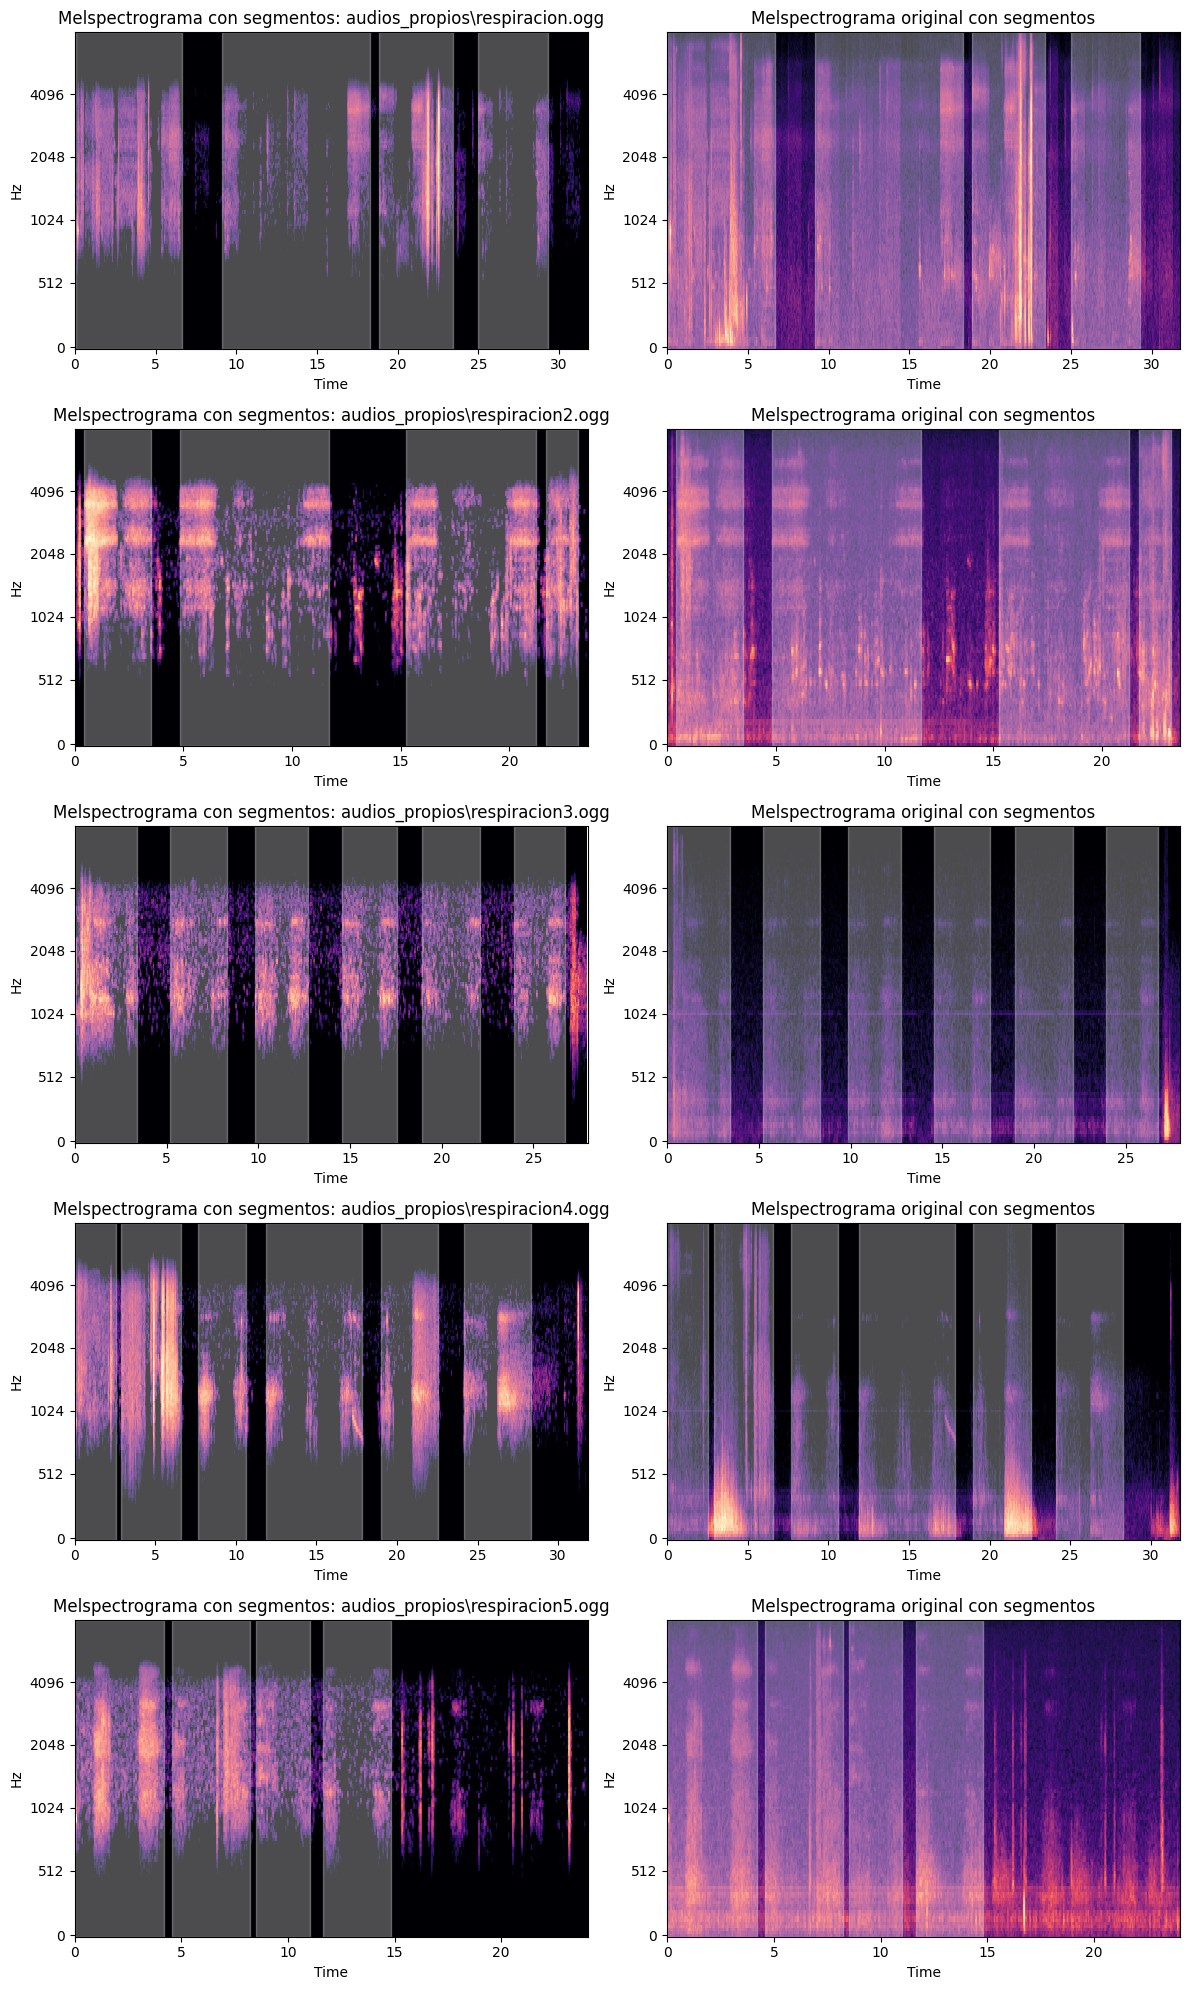

In [7]:
fig, axes = plt.subplots(len(paths), 2, figsize=(12, len(paths) * 4))

for i, path in enumerate(paths):
    y, sr = librosa.load(path, sr=SAMPLING_RATE)

    y_proc, sr_proc = filter_and_resample(path, lowcut=1000) #bandpass
    # y_proc = normalize_robust(y_proc, percentile=99)
    y_proc, sr_proc = spectral_subtract(y_proc, sr_proc, alpha=1.5)
    segments = segmentar_energy_based(y_proc, sr_proc, min_duration=0.5, percentile=50)

    plot_mel_with_segments(y_proc, sr_proc, segments, ax=axes[i, 0])
    axes[i, 0].set_title(f"Melspectrograma con segmentos: {path.split('/')[-1]}")
    plot_mel_with_segments(y, sr, segments, ax=axes[i, 1])
    axes[i, 1].set_title("Melspectrograma original con segmentos")

plt.tight_layout()
plt.show()


La segmentación jamás será perfecta, el modelo debería ser lo suficientemente robusto para poder funcionar de manera casi optima con estos ciclos imperfectos.

Guardamos los ciclos

In [70]:
output_folder = '../audios_propios/ciclos_energy_based'
os.makedirs(output_folder, exist_ok=True)

for path in paths:
    y, sr = filter_and_resample(path)  # audio original

    # procesamiento para encontrar ciclos, no es el procesamiento final
    y_proc, sr_proc = filter_and_resample(path, lowcut=1_000, highcut=4_000)  # audio procesado, bandpass 1000-4000
    # y = normalize_robust(y, percentile=99)
    y_proc, sr_proc = spectral_subtract(y_proc, sr_proc, alpha=1.5)
    segments = segmentar_energy_based(y_proc, sr_proc, min_duration=0.5, percentile=50)
    base_name = os.path.basename(path).replace('.ogg', '')
    
    for i, (start, end) in enumerate(segments, start=1):
        segment = y[int(start * sr):int(end * sr)]
        sf.write(f"{output_folder}/{base_name}_ciclo_{i}.wav", segment, sr)

Vamos a ver un mel

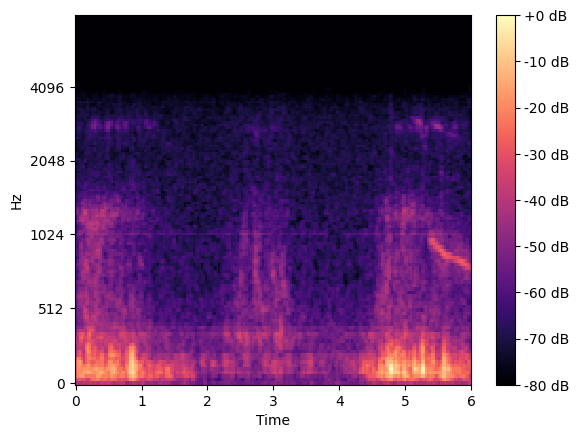

In [73]:
y, sr = filter_and_resample('../audios_propios/ciclos_energy_based/respiracion4_ciclo_4.wav')

# plot melspec
melspec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
melspec_db = librosa.power_to_db(melspec, ref=np.max)
librosa.display.specshow(melspec_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format="%+2.0f dB")

Puede ser que haya que agregar un poco mas de margen para que no termine de manera tan abrupta

Veamos algunos ciclos con wheeze true

In [10]:
df = pd.read_csv('../icbhi/ICBHI_ciclos/ICBHI_ciclos_metadata.csv')

In [11]:
df['label'] = np.where((df['crackles'] == 0) & (df['wheezes'] == 0), 0, 1)
df = df[(df['instrument'] == 'AKGC417L') | (df['location'] == 'Tc')].copy()

In [30]:
paths_icbhi = df[df['label'] == 1].sample(5).cycle_wav_file

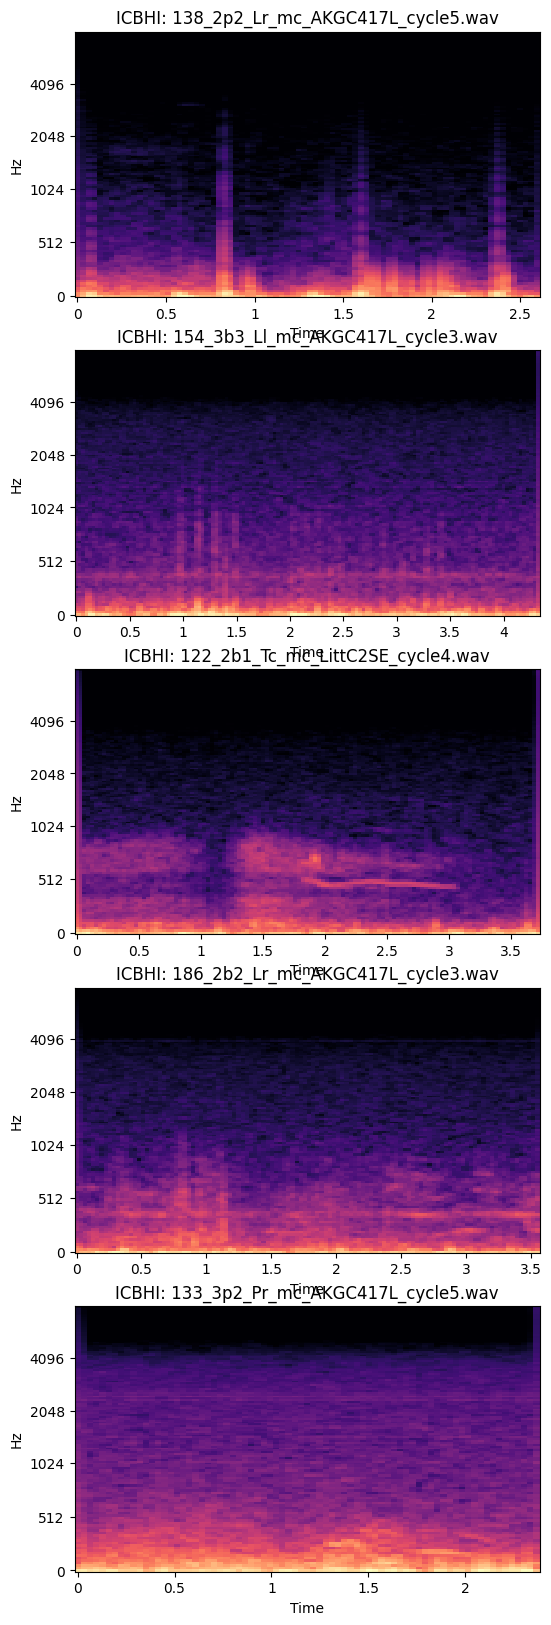

In [31]:
fig, axes = plt.subplots(len(paths_icbhi), 1, figsize=(6, 4 * len(paths_icbhi)))

for i, path in enumerate(paths_icbhi):
    y, sr = filter_and_resample(f"../icbhi/ICBHI_ciclos/{path}") # bandpass
    melspec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    melspec_db = librosa.power_to_db(melspec, ref=np.max)
    img = librosa.display.specshow(
        melspec_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[i]
    )
    axes[i].set_title(f"ICBHI: {path}")